# Multi-Method OI Cap Implementation

## Executive Summary

This notebook implements three complementary methodologies for calculating maximum **Open Interest (OI) caps** for cryptocurrency derivatives:

1. **Square-Root Price Impact Law** — Empirically validated model based on order flow invariance (Almgren & Chriss 2000, Bouchaud et al. 2009)
2. **VWAP Slippage Models** — Industry-standard execution benchmark calibrated from historical kline data
3. **Amihud ILLIQ Ratio** — Liquidity-based OI cap from Notebook 01

The final recommendation uses a **conservative multi-method framework**:

$$OI_{\text{recommended}} = \min(OI_{\text{sqrtlaw}},\ OI_{\text{vwap}},\ OI_{\text{illiq}})$$

**Key Principle**: The maximum OI should be set such that liquidating the entire position causes at most 5% price impact (matching the maintenance margin threshold), ensuring vault solvency under forced liquidation.

## 1. Setup and Data Loading

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
from IPython.display import HTML, display
import warnings
from pathlib import Path
import sys

# Configure display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
warnings.filterwarnings('ignore')

# Visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# ============================================================================
# CONSTANTS
# ============================================================================
SYMBOLS = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'DOGEUSDT', 'SUIUSDT']
DATA_DIR = Path('../../data')
KLINES_DIR = DATA_DIR / 'klines'
RESULTS_DIR = Path('./results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Model parameters
SLIPPAGE_MAX = 0.05        # 5% maximum acceptable slippage (= maintenance margin)
Y_DEFAULT = 1.0            # Square-root impact coefficient
ALPHA = 0.4                # Safety factor for ILLIQ-based OI cap
MM = 0.05                  # Maintenance margin (5%)
LIQUIDATION_WINDOW = '60min' # 1-hour liquidation horizon

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================
def calculate_subplot_grid(n_plots):
    if n_plots <= 1: return 1, 1
    elif n_plots == 2: return 1, 2
    elif n_plots <= 4: return 2, 2
    elif n_plots <= 6: return 3, 2
    else: return int(np.ceil(n_plots / 2)), 2

def fmt_dollars(x):
    if pd.isna(x) or x == 0:
        return '$0'
    if abs(x) >= 1e12:
        return f'${x/1e12:,.1f}T'
    elif abs(x) >= 1e9:
        return f'${x/1e9:,.2f}B'
    elif abs(x) >= 1e6:
        return f'${x/1e6:,.1f}M'
    elif abs(x) >= 1e3:
        return f'${x/1e3:,.0f}K'
    else:
        return f'${x:,.0f}'

print("Environment initialized")
print(f"Symbols: {', '.join(SYMBOLS)}")
print(f"Slippage max: {SLIPPAGE_MAX*100:.0f}%, Y: {Y_DEFAULT}, alpha: {ALPHA}, MM: {MM*100:.0f}%")

Environment initialized
Symbols: BTCUSDT, ETHUSDT, SOLUSDT, DOGEUSDT, SUIUSDT
Slippage max: 5%, Y: 1.0, alpha: 0.4, MM: 5%


### Data Loading

In [2]:
def load_klines(symbol):
    filepath = KLINES_DIR / f"{symbol}_1m.csv"
    df = pd.read_csv(filepath)
    df['open_time'] = pd.to_datetime(df['open_time'])
    df.set_index('open_time', inplace=True)
    df = df[df.index >= '2025-01-01']  # Filter to data from 2025-01-01 onwards
    df['symbol'] = symbol
    cols = ['open', 'high', 'low', 'close', 'volume', 'quote_volume', 'symbol']
    df = df[[c for c in cols if c in df.columns]]
    return df

# Load all klines data
klines = {}
for symbol in SYMBOLS:
    try:
        klines[symbol] = load_klines(symbol)
        df = klines[symbol]
        print(f"  {symbol}: {len(df):>10,} records  "
              f"({df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')})")
    except FileNotFoundError as e:
        print(f"  {symbol}: MISSING - {e}")

  BTCUSDT:    525,601 records  (2025-01-01 to 2026-01-01)
  ETHUSDT:    525,601 records  (2025-01-01 to 2026-01-01)
  SOLUSDT:    525,601 records  (2025-01-01 to 2026-01-01)
  DOGEUSDT:    525,601 records  (2025-01-01 to 2026-01-01)
  SUIUSDT:    525,601 records  (2025-01-01 to 2026-01-01)


In [3]:
quality = []
for symbol, df in klines.items():
    if 'quote_volume' in df.columns:
        dollar_vol = df['quote_volume']
    else:
        dollar_vol = df['close'] * df['volume']

    quality.append({
        'Symbol': symbol,
        'Records': f"{len(df):,}",
        'Start': df.index.min().strftime('%Y-%m-%d'),
        'End': df.index.max().strftime('%Y-%m-%d'),
        'Days': (df.index.max() - df.index.min()).days,
        'Zero Vol %': f"{(df['volume'] == 0).mean() * 100:.3f}",
        'Avg Daily $Vol': f"${dollar_vol.resample('D').sum().mean():,.0f}"
    })

display(HTML('<h4 style="text-align: center; margin-top: 15px; margin-bottom: 5px; font-weight: bold;">Data Quality Summary</h4>'))
display(pd.DataFrame(quality))

,Symbol,Records,Start,End,Days,Zero Vol %,Avg Daily $Vol
0,BTCUSDT,"525,601",2025-01-01,2026-01-01,365,0.003,"$16,703,474,668"
1,ETHUSDT,"525,601",2025-01-01,2026-01-01,365,0.003,"$15,417,634,299"
2,SOLUSDT,"525,601",2025-01-01,2026-01-01,365,0.004,"$4,198,143,948"
3,DOGEUSDT,"525,601",2025-01-01,2026-01-01,365,0.004,"$1,474,449,856"
4,SUIUSDT,"525,601",2025-01-01,2026-01-01,365,0.004,"$773,418,128"


## 2. Preliminary Calculations

Before computing OI caps, we calculate the foundational metrics used by all three methods:

1. **Parkinson Volatility** — Range-based volatility estimator using High-Low prices:
$$\sigma^2_{\text{Parkinson},t} = \frac{1}{4 \ln(2)} \left( \ln\frac{H_t}{L_t} \right)^2$$

2. **Hourly Volatility for Square-Root Law** — Scaled from per-minute Parkinson: $\sigma_{\text{1h}} = \sigma_{1m} \times \sqrt{60}$
   - Uses **hourly volatility** to match the 1-hour liquidation window time scale
   - **Critical**: σ and V must be measured over the **same time scale** for dimensional consistency
   - The participation rate Q/V_1h must be dimensionless

3. **Rolling 1-Hour Dollar Volume** — Total dollar volume in trailing 60 minutes, smoothed with 24h rolling average for stability.

In [4]:
def calculate_parkinson_volatility(df, window=60):
    hl_ratio = np.log(df['high'] / df['low'])
    parkinson_var = (1 / (4 * np.log(2))) * (hl_ratio ** 2)
    volatility = np.sqrt(parkinson_var.rolling(window=window).mean())
    return volatility

print("Calculating preliminary metrics...")
print("=" * 70)

for symbol in SYMBOLS:
    if symbol not in klines:
        continue
    df = klines[symbol]

    # 1. Parkinson volatility (per-minute, 60-min rolling window)
    df['vol_parkinson'] = calculate_parkinson_volatility(df, window=60)

    # 2. Hourly volatility for Square-Root Law: sigma_1h = sigma_1m * sqrt(60)
    # CRITICAL: Use hourly volatility with hourly volume for dimensional consistency
    # The participation rate Q/V_1h must be dimensionless, requiring matching time scales
    df['vol_1h'] = df['vol_parkinson'] * np.sqrt(60)  # 60 minutes per hour

    # 3. Dollar volume per minute
    if 'quote_volume' in df.columns:
        df['dollar_volume'] = df['quote_volume']
    else:
        df['dollar_volume'] = df['close'] * df['volume']

    # 4. Rolling 1h dollar volume
    df['dollar_volume_1h'] = df['dollar_volume'].rolling(LIQUIDATION_WINDOW).sum()

    # 5. 24h-smoothed 1h volume (stable estimate for OI cap)
    df['dollar_volume_1h_avg'] = df['dollar_volume_1h'].rolling('24h').mean()

    vol_1h_mean = df['vol_1h'].mean()
    dv_1h_mean = df['dollar_volume_1h_avg'].mean()
    print(f"\n{symbol}:")
    print(f"  sigma_1h (mean): {vol_1h_mean*100:.4f}%")
    print(f"  V_1h smoothed (mean): {fmt_dollars(dv_1h_mean)}")

Calculating preliminary metrics...

BTCUSDT:
  sigma_1h (mean): 0.3559%
  V_1h smoothed (mean): $697.7M

ETHUSDT:
  sigma_1h (mean): 0.6363%
  V_1h smoothed (mean): $643.9M

SOLUSDT:
  sigma_1h (mean): 0.7639%
  V_1h smoothed (mean): $175.3M

DOGEUSDT:
  sigma_1h (mean): 0.8191%
  V_1h smoothed (mean): $61.6M

SUIUSDT:
  sigma_1h (mean): 0.9506%
  V_1h smoothed (mean): $32.3M


## 3. Method 1 — Square-Root Price Impact Law

### Theory

The Square-Root Price Impact Law is one of the most robust empirical findings in market microstructure. It states that the price impact of executing an order of size $Q$ scales as the square root of the participation rate:

$$\text{Slippage}_{\%} = Y \cdot \sigma_{1h} \cdot \sqrt{\frac{Q}{V_{1h}}}$$

where:
- $Y \in [0.5, 1.5]$ — impact coefficient (we use $Y = 1.0$ as default)
- $\sigma_{1h}$ — **hourly volatility** (Parkinson estimator: $\sigma_{1m} \times \sqrt{60}$)
- $Q$ — order size in dollars (= OI to liquidate)
- $V_{1h}$ — hourly dollar volume (24h-smoothed for stability)

**Dimensional Consistency** (Critical): 
- $Q/V_{1h}$ is the **participation rate** and must be **dimensionless**
- This requires $\sigma$ and $V$ to be measured over the **same time scale**
- For 1-hour liquidation window: use hourly volatility ($\sigma_{1h}$) with hourly volume ($V_{1h}$)
- Dimensional analysis confirms this is the unique scaling law (Bouchaud et al. 2009)

**OI Cap Derivation**: Setting $\text{Slippage}_{\%} = 5\%$ (maintenance margin) and solving for $Q$:

$$OI_{\text{sqrtlaw}} = V_{1h} \times \left( \frac{\text{Slippage}_{\text{max}}}{Y \cdot \sigma_{1h}} \right)^2$$

**References:**
- Almgren & Chriss (2000), "Optimal Execution of Portfolio Transactions"
- Bouchaud et al. (2009), "How Markets Slowly Digest Changes in Supply and Demand"
- Toth et al. (2011), "Anomalous Price Impact and the Critical Nature of Liquidity"

In [5]:
def calculate_oi_sqrtlaw(vol_1h, dollar_volume_1h, Y=1.0, slippage_max=0.05):
    """
    Square-Root Price Impact Law with dimensionally consistent time scales.
    
    OI_max = V_1h * (slippage_max / (Y * sigma_1h))^2
    
    For 1-hour liquidation window:
    - vol_1h: hourly volatility (σ_1m × √60)
    - dollar_volume_1h: hourly dollar volume
    - Participation rate Q/V_1h is dimensionless ✓
    """
    oi_cap = dollar_volume_1h * (slippage_max / (Y * vol_1h)) ** 2
    oi_cap = oi_cap.replace([np.inf, -np.inf], np.nan)
    return oi_cap.clip(lower=0)

# Calculate OI_sqrtlaw for all symbols
print("Square-Root OI Caps")
print(f"Parameters: Y={Y_DEFAULT}, Slippage_max={SLIPPAGE_MAX*100:.0f}%")
print("=" * 70)

sqrtlaw_summary = []
for symbol in SYMBOLS:
    if symbol not in klines:
        continue
    df = klines[symbol]
    df['OI_sqrtlaw'] = calculate_oi_sqrtlaw(
        df['vol_1h'], df['dollar_volume_1h_avg'],
        Y=Y_DEFAULT, slippage_max=SLIPPAGE_MAX
    )

    valid = df['OI_sqrtlaw'].dropna()
    sqrtlaw_summary.append({
        'Symbol': symbol,
        'OI Mean': valid.mean(),
        'OI Median': valid.median(),
        'OI P10': valid.quantile(0.10),
        'OI P90': valid.quantile(0.90),
    })
    print(f"  {symbol}: Median={fmt_dollars(valid.median())}, "
          f"P10={fmt_dollars(valid.quantile(0.10))}, "
          f"P90={fmt_dollars(valid.quantile(0.90))}")

Square-Root OI Caps
Parameters: Y=1.0, Slippage_max=5%
  BTCUSDT: Median=$191.34B, P10=$45.48B, P90=$694.00B
  ETHUSDT: Median=$49.47B, P10=$13.18B, P90=$155.17B
  SOLUSDT: Median=$9.08B, P10=$2.95B, P90=$23.14B
  DOGEUSDT: Median=$2.66B, P10=$845.6M, P90=$6.71B
  SUIUSDT: Median=$1.05B, P10=$341.5M, P90=$2.73B


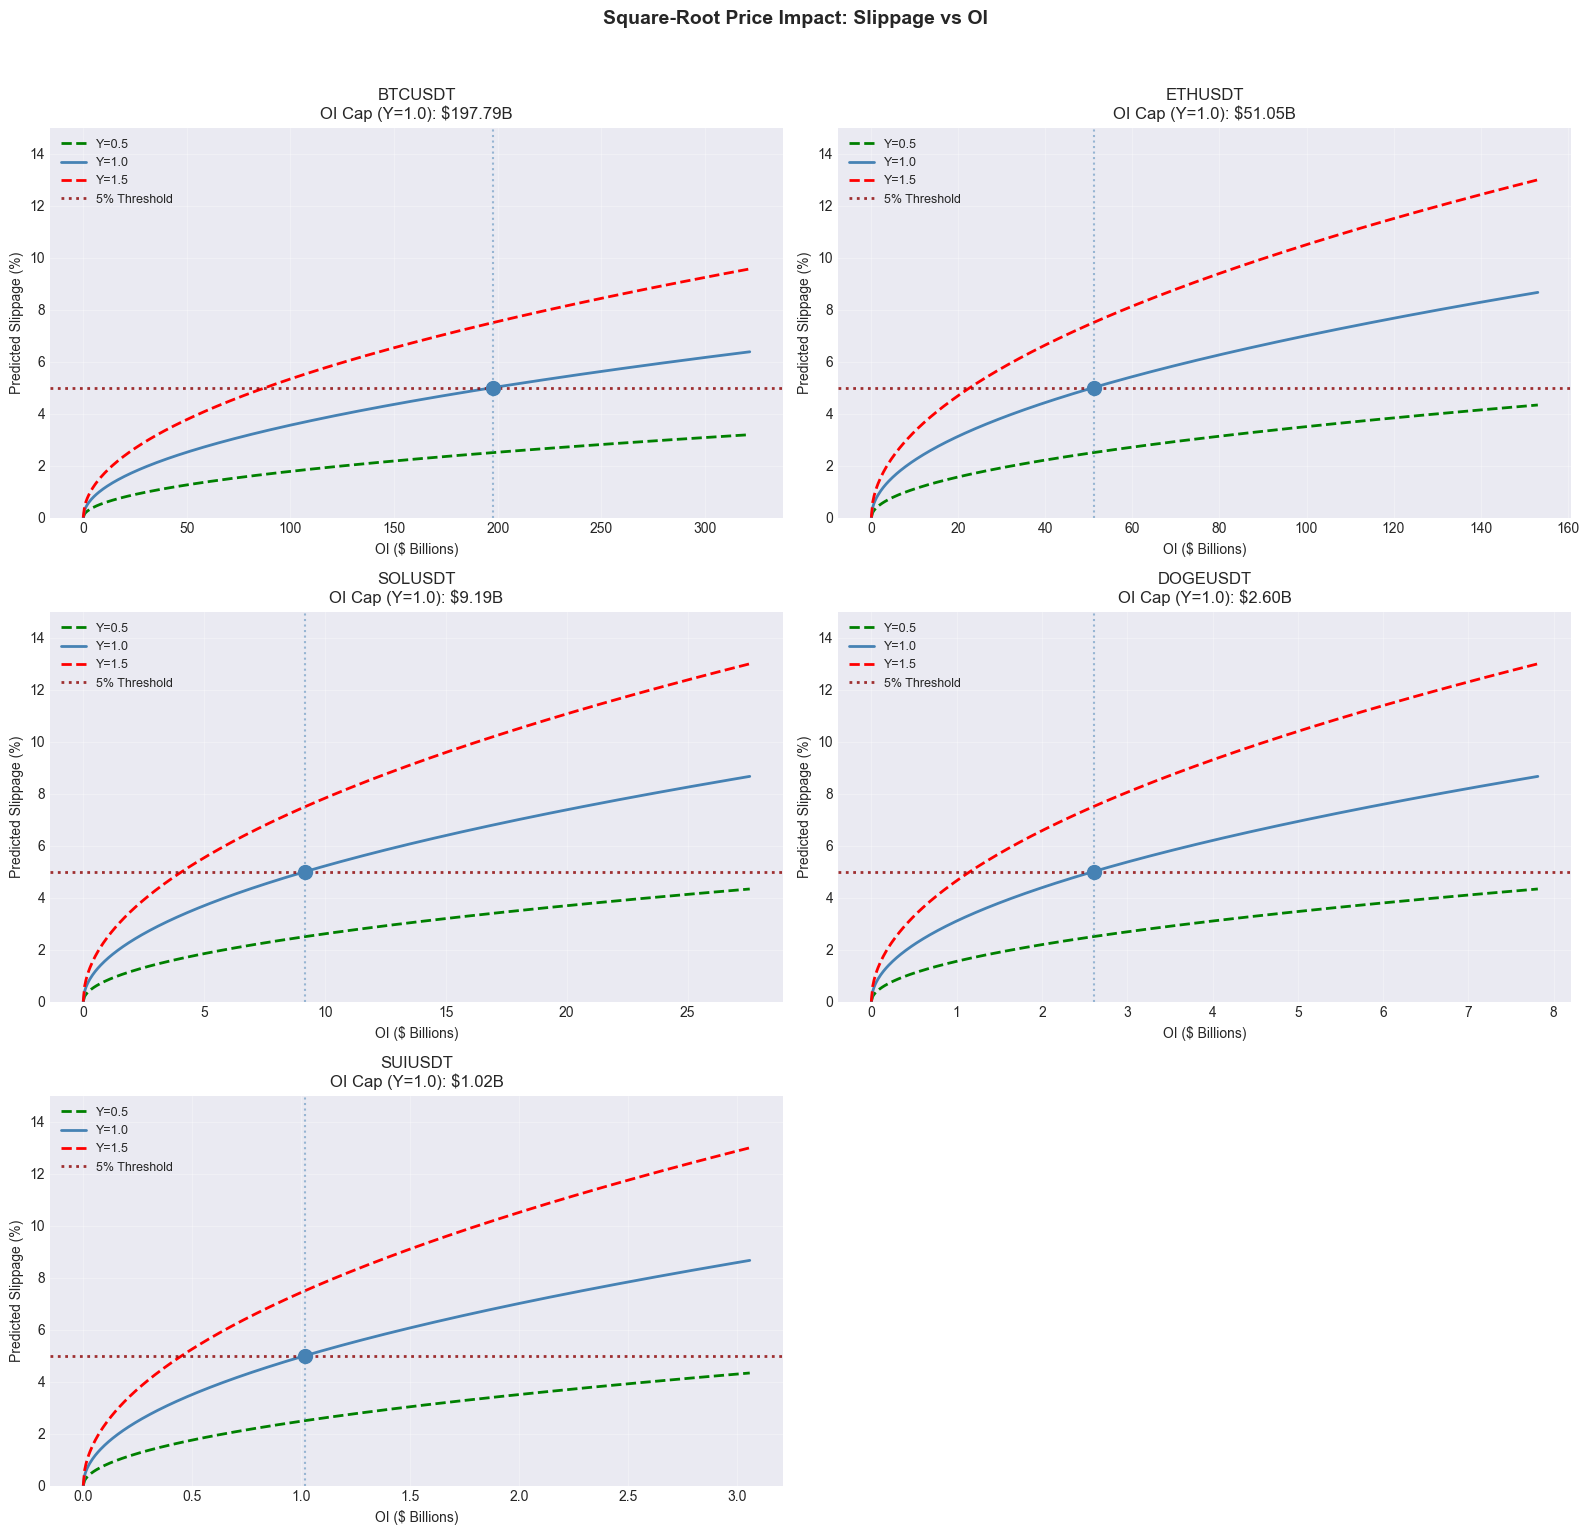

In [6]:
# Visualize slippage curves for each symbol
n = len([s for s in SYMBOLS if s in klines])
nrows, ncols = calculate_subplot_grid(n)
fig, axes = plt.subplots(nrows, ncols, figsize=(8*ncols, 5*nrows))
if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, symbol in enumerate([s for s in SYMBOLS if s in klines]):
    ax = axes[idx]
    df = klines[symbol]

    # Use median values for the curve
    vol_1h_med = df['vol_1h'].median()
    dv_1h_med = df['dollar_volume_1h_avg'].median()

    # OI range
    oi_cap_y1 = dv_1h_med * (SLIPPAGE_MAX / (1.0 * vol_1h_med)) ** 2
    oi_range = np.linspace(0, min(oi_cap_y1 * 3, dv_1h_med * 500), 500)

    # Plot slippage curves for different Y values
    for Y_val, color, ls in [(0.5, 'green', '--'), (1.0, 'steelblue', '-'), (1.5, 'red', '--')]:
        slippage = Y_val * vol_1h_med * np.sqrt(oi_range / dv_1h_med) * 100
        ax.plot(oi_range / 1e9, slippage, color=color, linestyle=ls, linewidth=2,
                label=f'Y={Y_val}')

    # 5% threshold
    ax.axhline(y=5, color='darkred', linestyle=':', linewidth=2, alpha=0.8, label='5% Threshold')

    # Mark OI cap for Y=1.0
    oi_cap = dv_1h_med * (SLIPPAGE_MAX / (Y_DEFAULT * vol_1h_med)) ** 2
    ax.axvline(x=oi_cap / 1e9, color='steelblue', linestyle=':', alpha=0.5)
    ax.plot(oi_cap / 1e9, 5, 'o', color='steelblue', markersize=10, zorder=5)

    ax.set_xlabel('OI ($ Billions)')
    ax.set_ylabel('Predicted Slippage (%)')
    ax.set_title(f'{symbol}\nOI Cap (Y=1.0): {fmt_dollars(oi_cap)}')
    ax.legend(fontsize=9, loc='upper left')
    ax.set_ylim(0, 15)
    ax.grid(True, alpha=0.3)

for idx in range(n, nrows * ncols):
    fig.delaxes(axes[idx])

plt.suptitle('Square-Root Price Impact: Slippage vs OI', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
sqrtlaw_df = pd.DataFrame(sqrtlaw_summary)
display(HTML('<h4 style="text-align: center; margin-top: 15px; margin-bottom: 5px; font-weight: bold;">Square-Root Price Impact — OI Cap Summary</h4>'))
display(sqrtlaw_df.style.format({
    'OI Mean': lambda x: fmt_dollars(x),
    'OI Median': lambda x: fmt_dollars(x),
    'OI P10': lambda x: fmt_dollars(x),
    'OI P90': lambda x: fmt_dollars(x),
}))

,Symbol,OI Mean,OI Median,OI P10,OI P90
0,BTCUSDT,$320.80B,$191.34B,$45.48B,$694.00B
1,ETHUSDT,$72.73B,$49.47B,$13.18B,$155.17B
2,SOLUSDT,$11.69B,$9.08B,$2.95B,$23.14B
3,DOGEUSDT,$3.35B,$2.66B,$845.6M,$6.71B
4,SUIUSDT,$1.35B,$1.05B,$341.5M,$2.73B


## 4. Method 2 — VWAP Slippage Model

### Theory

The **VWAP (Volume-Weighted Average Price)** slippage model estimates price impact by analyzing the empirical relationship between trading volume and price deviations from VWAP.

**Approach:**
1. Calculate hourly VWAP: $\text{VWAP}_{1h} = \frac{\sum P_i \times V_i}{\sum V_i}$
2. Measure hourly slippage: maximum deviation of High/Low from VWAP
3. Normalize volume: $\text{vol\_ratio} = \frac{V_{\text{hour}}}{V_{\text{7d\_median}}}$
4. Fit empirical relationship: $\text{Slippage}_{P95} = \beta \times \sqrt{\text{vol\_ratio}}$
5. **OI Cap**: If liquidating OI over 1 hour adds to normal volume:

$$OI_{\text{vwap}} = V_{1h}^{\text{normal}} \times \left[ \left(\frac{\text{Slippage}_{\text{max}}}{\beta}\right)^2 - 1 \right]$$

**Note**: This method calibrates $\beta$ empirically from the data, making it symbol-specific. It captures the actual market behavior but relies on extrapolation beyond observed volume levels.

**References:**
- Berkowitz et al. (1988), "Total Cost of Transactions on the NYSE"
- Kissell & Glantz (2003), *Optimal Trading Strategies*

In [8]:
def sqrt_model(x, beta):
    return beta * np.sqrt(x)

# Fit VWAP slippage model for each symbol
vwap_params = {}

print("VWAP Slippage Model Calibration")
print("=" * 70)

for symbol in SYMBOLS:
    if symbol not in klines:
        continue
    df = klines[symbol]

    # Resample to hourly
    agg_dict = {'high': 'max', 'low': 'min', 'close': 'last', 'volume': 'sum'}
    if 'quote_volume' in df.columns:
        agg_dict['quote_volume'] = 'sum'
    hourly = df.resample('1h').agg(agg_dict).dropna()

    # Hourly VWAP
    if 'quote_volume' in hourly.columns and hourly['volume'].sum() > 0:
        hourly['vwap'] = hourly['quote_volume'] / hourly['volume'].replace(0, np.nan)
    else:
        hourly['vwap'] = hourly['close']

    # Hourly slippage (max deviation from VWAP)
    hourly['slippage_up'] = (hourly['high'] - hourly['vwap']).abs() / hourly['vwap']
    hourly['slippage_down'] = (hourly['vwap'] - hourly['low']).abs() / hourly['vwap']
    hourly['slippage'] = hourly[['slippage_up', 'slippage_down']].max(axis=1)

    # Hourly dollar volume
    if 'quote_volume' in hourly.columns:
        hourly['dollar_volume'] = hourly['quote_volume']
    else:
        hourly['dollar_volume'] = hourly['close'] * hourly['volume']

    # Volume ratio (normalized by 7-day rolling median)
    hourly['vol_7d_median'] = hourly['dollar_volume'].rolling('7d', min_periods=24).median()
    hourly['vol_ratio'] = hourly['dollar_volume'] / hourly['vol_7d_median']

    # Filter valid data
    mask = (
        hourly['vol_ratio'].notna() &
        (hourly['vol_ratio'] > 0.01) &
        (hourly['vol_ratio'] < hourly['vol_ratio'].quantile(0.99)) &
        hourly['slippage'].notna() &
        (hourly['slippage'] > 0) &
        (hourly['slippage'] < hourly['slippage'].quantile(0.99))
    )
    hourly_clean = hourly[mask].copy()

    # Bin by volume ratio and compute P95 slippage
    try:
        n_bins = 20
        hourly_clean['vol_bin'] = pd.qcut(hourly_clean['vol_ratio'], q=n_bins, duplicates='drop')
        binned = hourly_clean.groupby('vol_bin', observed=True).agg(
            slippage_p95=('slippage', lambda x: x.quantile(0.95)),
            vol_ratio_med=('vol_ratio', 'median')
        ).dropna()

        # Fit square-root model
        popt, pcov = curve_fit(
            sqrt_model,
            binned['vol_ratio_med'].values,
            binned['slippage_p95'].values,
            p0=[0.01], maxfev=5000
        )
        beta = abs(popt[0])

        # R-squared
        y_pred = sqrt_model(binned['vol_ratio_med'].values, beta)
        ss_res = np.sum((binned['slippage_p95'].values - y_pred) ** 2)
        ss_tot = np.sum((binned['slippage_p95'].values - binned['slippage_p95'].mean()) ** 2)
        r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else 0

    except Exception as e:
        print(f"  {symbol}: curve_fit failed ({e}), using fallback")
        beta = hourly_clean['slippage'].quantile(0.95)
        r_squared = 0.0
        binned = None

    # Calculate OI cap (static, using median hourly volume)
    V_1h_median = hourly['dollar_volume'].median()
    ratio_term = (SLIPPAGE_MAX / beta) ** 2 - 1
    oi_vwap_static = V_1h_median * max(ratio_term, 0)

    vwap_params[symbol] = {
        'beta': beta, 'r_squared': r_squared,
        'V_1h_median': V_1h_median, 'OI_vwap': oi_vwap_static,
        'binned': binned, 'hourly_clean': hourly_clean,
    }

    print(f"\n{symbol}:")
    print(f"  beta = {beta:.6f} (R^2 = {r_squared:.3f})")
    print(f"  V_1h median = {fmt_dollars(V_1h_median)}")
    print(f"  OI_vwap (static) = {fmt_dollars(oi_vwap_static)}")

    # Time-varying OI cap (using smoothed 1h volume)
    ratio_val = max((SLIPPAGE_MAX / beta) ** 2 - 1, 0)
    df['OI_vwap'] = df['dollar_volume_1h_avg'] * ratio_val
    df['OI_vwap'] = df['OI_vwap'].replace([np.inf, -np.inf], np.nan).clip(lower=0)

VWAP Slippage Model Calibration

BTCUSDT:
  beta = 0.005781 (R^2 = 0.949)
  V_1h median = $471.9M
  OI_vwap (static) = $34.83B

ETHUSDT:
  beta = 0.009400 (R^2 = 0.955)
  V_1h median = $441.6M
  OI_vwap (static) = $12.05B

SOLUSDT:
  beta = 0.011499 (R^2 = 0.956)
  V_1h median = $127.1M
  OI_vwap (static) = $2.28B

DOGEUSDT:
  beta = 0.012422 (R^2 = 0.954)
  V_1h median = $41.3M
  OI_vwap (static) = $627.8M

SUIUSDT:
  beta = 0.014247 (R^2 = 0.944)
  V_1h median = $23.5M
  OI_vwap (static) = $266.1M


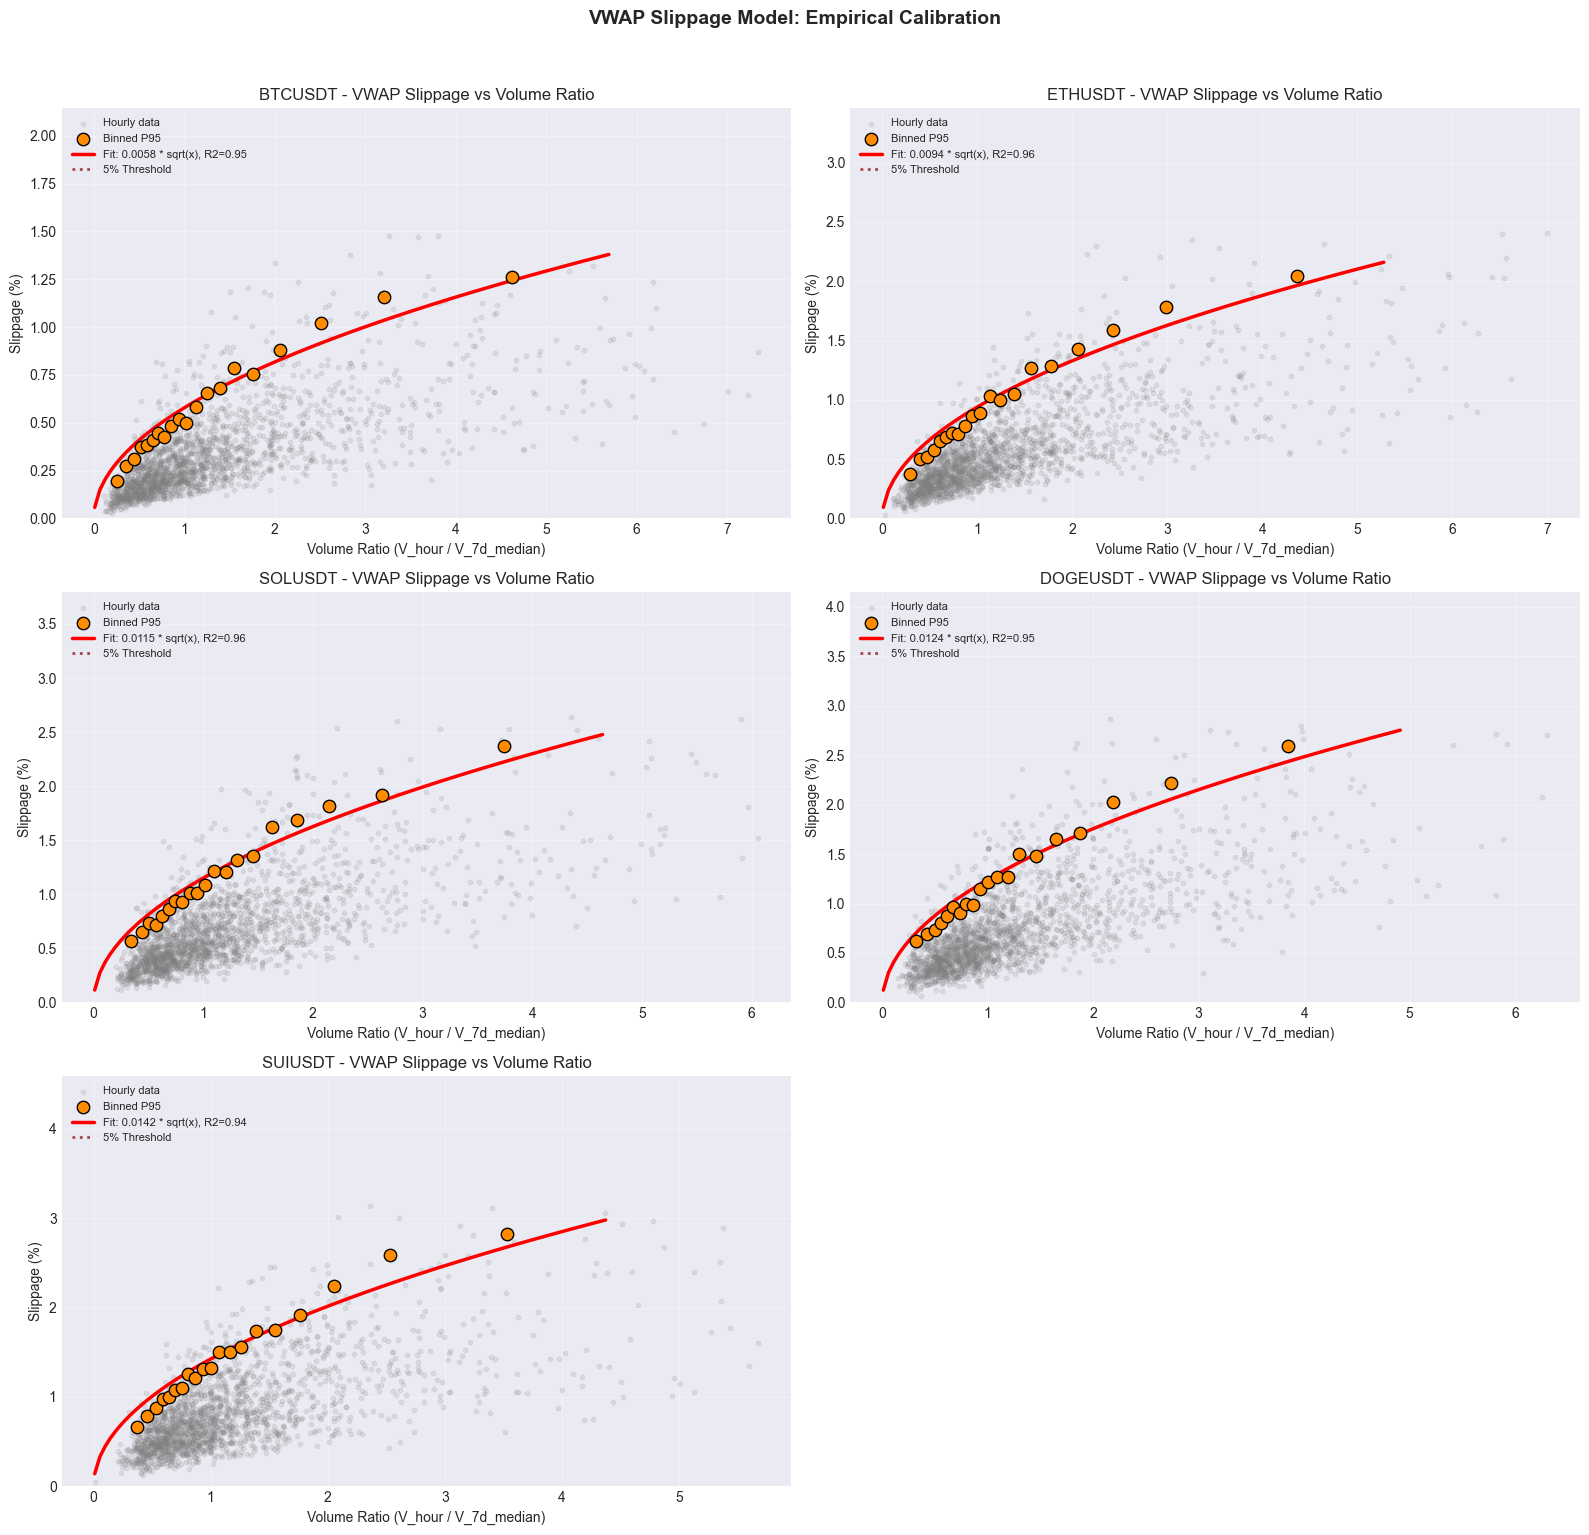

In [9]:
# Visualize VWAP regression for each symbol
n = len([s for s in SYMBOLS if s in vwap_params])
nrows, ncols = calculate_subplot_grid(n)
fig, axes = plt.subplots(nrows, ncols, figsize=(8*ncols, 5*nrows))
if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, symbol in enumerate([s for s in SYMBOLS if s in vwap_params]):
    ax = axes[idx]
    params = vwap_params[symbol]
    hourly_clean = params['hourly_clean']
    binned = params['binned']
    beta = params['beta']
    r2 = params['r_squared']

    # Scatter: raw hourly data (subsample for performance)
    sample = hourly_clean.sample(min(2000, len(hourly_clean)), random_state=42)
    ax.scatter(sample['vol_ratio'], sample['slippage'] * 100,
               alpha=0.15, s=10, color='gray', label='Hourly data')

    # Binned P95 points
    if binned is not None:
        ax.scatter(binned['vol_ratio_med'], binned['slippage_p95'] * 100,
                   color='darkorange', s=80, zorder=5, edgecolors='black', linewidth=1,
                   label='Binned P95')

    # Regression line
    x_fit = np.linspace(0.01, hourly_clean['vol_ratio'].quantile(0.99), 100)
    y_fit = sqrt_model(x_fit, beta) * 100
    ax.plot(x_fit, y_fit, 'r-', linewidth=2.5,
            label=f'Fit: {beta:.4f} * sqrt(x), R2={r2:.2f}')

    # 5% threshold
    ax.axhline(y=5, color='darkred', linestyle=':', linewidth=2, alpha=0.7, label='5% Threshold')

    ax.set_xlabel('Volume Ratio (V_hour / V_7d_median)')
    ax.set_ylabel('Slippage (%)')
    ax.set_title(f'{symbol} - VWAP Slippage vs Volume Ratio')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_ylim(0, min(15, hourly_clean['slippage'].quantile(0.999) * 100 * 1.5))
    ax.grid(True, alpha=0.3)

for idx in range(n, nrows * ncols):
    fig.delaxes(axes[idx])

plt.suptitle('VWAP Slippage Model: Empirical Calibration', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
vwap_summary = []
for symbol in SYMBOLS:
    if symbol not in vwap_params:
        continue
    p = vwap_params[symbol]
    df = klines[symbol]
    valid = df['OI_vwap'].dropna()
    vwap_summary.append({
        'Symbol': symbol,
        'Beta': p['beta'],
        'R_squared': p['r_squared'],
        'V_1h Median': p['V_1h_median'],
        'OI Median': valid.median(),
        'OI P10': valid.quantile(0.10),
    })

vwap_df = pd.DataFrame(vwap_summary)
display(HTML('<h4 style="text-align: center; margin-top: 15px; margin-bottom: 5px; font-weight: bold;">VWAP Slippage Model — OI Cap Summary</h4>'))
display(vwap_df.style.format({
    'Beta': '{:.6f}',
    'R_squared': '{:.3f}',
    'V_1h Median': lambda x: fmt_dollars(x),
    'OI Median': lambda x: fmt_dollars(x),
    'OI P10': lambda x: fmt_dollars(x),
}))

,Symbol,Beta,R_squared,V_1h Median,OI Median,OI P10
0,BTCUSDT,0.005781,0.949,$471.9M,$47.47B,$21.66B
1,ETHUSDT,0.009400,0.955,$441.6M,$15.81B,$7.31B
2,SOLUSDT,0.011499,0.956,$127.1M,$2.73B,$1.53B
3,DOGEUSDT,0.012422,0.954,$41.3M,$753.7M,$354.5M
4,SUIUSDT,0.014247,0.944,$23.5M,$314.0M,$160.8M


## 5. Method 3 — Amihud ILLIQ Ratio

### Theory

The **Amihud Illiquidity Ratio** (2002) measures price impact per dollar traded:

$$\text{ILLIQ}_{24h} = \frac{|R_{24h}|}{\text{DollarVolume}_{24h}}$$

The OI cap is derived by setting the maximum position size such that liquidation slippage stays within the maintenance margin:

$$OI_{\text{illiq}} = \alpha \times \frac{MM}{\text{ILLIQ}_{24h}}$$

where:
- $\alpha = 0.4$ — safety factor
- $MM = 0.05$ — maintenance margin (5%)
- $\text{ILLIQ}_{24h}$ — 24-hour Amihud illiquidity ratio

This method was established in Notebook 01 and is included here for multi-method comparison.

**Reference:** Amihud (2002), "Illiquidity and Stock Returns", *Journal of Financial Markets*

In [11]:
# Import Amihud ILLIQ from src module
src_path = Path.cwd().parent.parent / 'src'
if str(src_path.resolve()) not in sys.path:
    sys.path.insert(0, str(src_path.resolve()))

from liquidity_metrics import calculate_rolling_illiq

print("Amihud ILLIQ OI Caps")
print(f"Parameters: alpha={ALPHA}, MM={MM*100:.0f}%")
print("=" * 70)

illiq_summary = []
for symbol in SYMBOLS:
    if symbol not in klines:
        continue
    df = klines[symbol]

    # Calculate rolling ILLIQ
    df_illiq = calculate_rolling_illiq(
        df[['open', 'high', 'low', 'close', 'volume']].copy(),
        windows=['24h', '7d']
    )
    df['ILLIQ_24h'] = df_illiq['ILLIQ_24h']

    # OI cap: alpha * MM / ILLIQ
    df['OI_illiq'] = ALPHA * MM / df['ILLIQ_24h']
    df['OI_illiq'] = df['OI_illiq'].replace([np.inf, -np.inf], np.nan).clip(lower=0)

    valid = df['OI_illiq'].dropna()
    illiq_summary.append({
        'Symbol': symbol,
        'ILLIQ_24h Mean': df['ILLIQ_24h'].mean(),
        'ILLIQ_24h Median': df['ILLIQ_24h'].median(),
        'OI Median': valid.median(),
        'OI P10': valid.quantile(0.10),
    })
    print(f"  {symbol}: ILLIQ_24h={df['ILLIQ_24h'].median():.2e}, "
          f"OI Median={fmt_dollars(valid.median())}, "
          f"OI P10={fmt_dollars(valid.quantile(0.10))}")

illiq_df = pd.DataFrame(illiq_summary)
display(HTML('<h4 style="text-align: center; margin-top: 15px; margin-bottom: 5px; font-weight: bold;">Amihud ILLIQ — OI Cap Summary</h4>'))
display(illiq_df.style.format({
    'ILLIQ_24h Mean': '{:.2e}',
    'ILLIQ_24h Median': '{:.2e}',
    'OI Median': lambda x: fmt_dollars(x),
    'OI P10': lambda x: fmt_dollars(x),
}))

Amihud ILLIQ OI Caps
Parameters: alpha=0.4, MM=5%
  BTCUSDT: ILLIQ_24h=2.02e-12, OI Median=$9.92B, OI P10=$6.68B
  ETHUSDT: ILLIQ_24h=4.04e-12, OI Median=$4.95B, OI P10=$2.69B
  SOLUSDT: ILLIQ_24h=1.71e-11, OI Median=$1.17B, OI P10=$723.8M
  DOGEUSDT: ILLIQ_24h=5.69e-11, OI Median=$351.8M, OI P10=$205.7M
  SUIUSDT: ILLIQ_24h=1.15e-10, OI Median=$174.5M, OI P10=$95.0M


,Symbol,ILLIQ_24h Mean,ILLIQ_24h Median,OI Median,OI P10
0,BTCUSDT,2.11e-12,2.02e-12,$9.92B,$6.68B
1,ETHUSDT,4.42e-12,4.04e-12,$4.95B,$2.69B
2,SOLUSDT,1.82e-11,1.71e-11,$1.17B,$723.8M
3,DOGEUSDT,6.24e-11,5.69e-11,$351.8M,$205.7M
4,SUIUSDT,1.36e-10,1.15e-10,$174.5M,$95.0M


## 6. Multi-Method Comparison & Recommendations

### Comparison Framework

The recommended OI cap uses a **conservative min() approach**:

$$OI_{\text{recommended}} = \min(OI_{\text{sqrtlaw}},\ OI_{\text{vwap}},\ OI_{\text{illiq}})$$

This ensures that the OI limit is never higher than what any single method deems safe. If methods diverge significantly (>5x), the asset is flagged for investigation.

In [12]:
# Build comparison table using median OI caps
comparison = []
for symbol in SYMBOLS:
    if symbol not in klines:
        continue
    df = klines[symbol]

    oi_sqrt_med = df['OI_sqrtlaw'].median()
    oi_vwap_med = df['OI_vwap'].median()
    oi_illiq_med = df['OI_illiq'].median()

    valid_ois = [x for x in [oi_sqrt_med, oi_vwap_med, oi_illiq_med]
                 if not pd.isna(x) and x > 0]
    oi_recommended = min(valid_ois) if valid_ois else np.nan
    divergence = max(valid_ois) / min(valid_ois) if len(valid_ois) > 1 else 1.0

    # Which method is most conservative?
    methods = {'SqrtLaw': oi_sqrt_med, 'VWAP': oi_vwap_med, 'ILLIQ': oi_illiq_med}
    binding = min(methods, key=lambda k: methods[k] if not pd.isna(methods[k]) else float('inf'))

    comparison.append({
        'Symbol': symbol,
        'OI SqrtLaw': oi_sqrt_med,
        'OI VWAP': oi_vwap_med,
        'OI ILLIQ': oi_illiq_med,
        'OI Recommended': oi_recommended,
        'Divergence': divergence,
        'Binding Method': binding,
    })

comp_df = pd.DataFrame(comparison)

display(HTML('<h3 style="text-align: center; margin-top: 20px; margin-bottom: 10px; font-weight: bold;">OI CAP COMPARISON (Median Values)</h3>'))
display(comp_df.style.format({
    'OI SqrtLaw': lambda x: fmt_dollars(x),
    'OI VWAP': lambda x: fmt_dollars(x),
    'OI ILLIQ': lambda x: fmt_dollars(x),
    'OI Recommended': lambda x: fmt_dollars(x),
    'Divergence': '{:.1f}x',
}))

,Symbol,OI SqrtLaw,OI VWAP,OI ILLIQ,OI Recommended,Divergence,Binding Method
0,BTCUSDT,$191.34B,$47.47B,$9.92B,$9.92B,19.3x,ILLIQ
1,ETHUSDT,$49.47B,$15.81B,$4.95B,$4.95B,10.0x,ILLIQ
2,SOLUSDT,$9.08B,$2.73B,$1.17B,$1.17B,7.8x,ILLIQ
3,DOGEUSDT,$2.66B,$753.7M,$351.8M,$351.8M,7.6x,ILLIQ
4,SUIUSDT,$1.05B,$314.0M,$174.5M,$174.5M,6.0x,ILLIQ


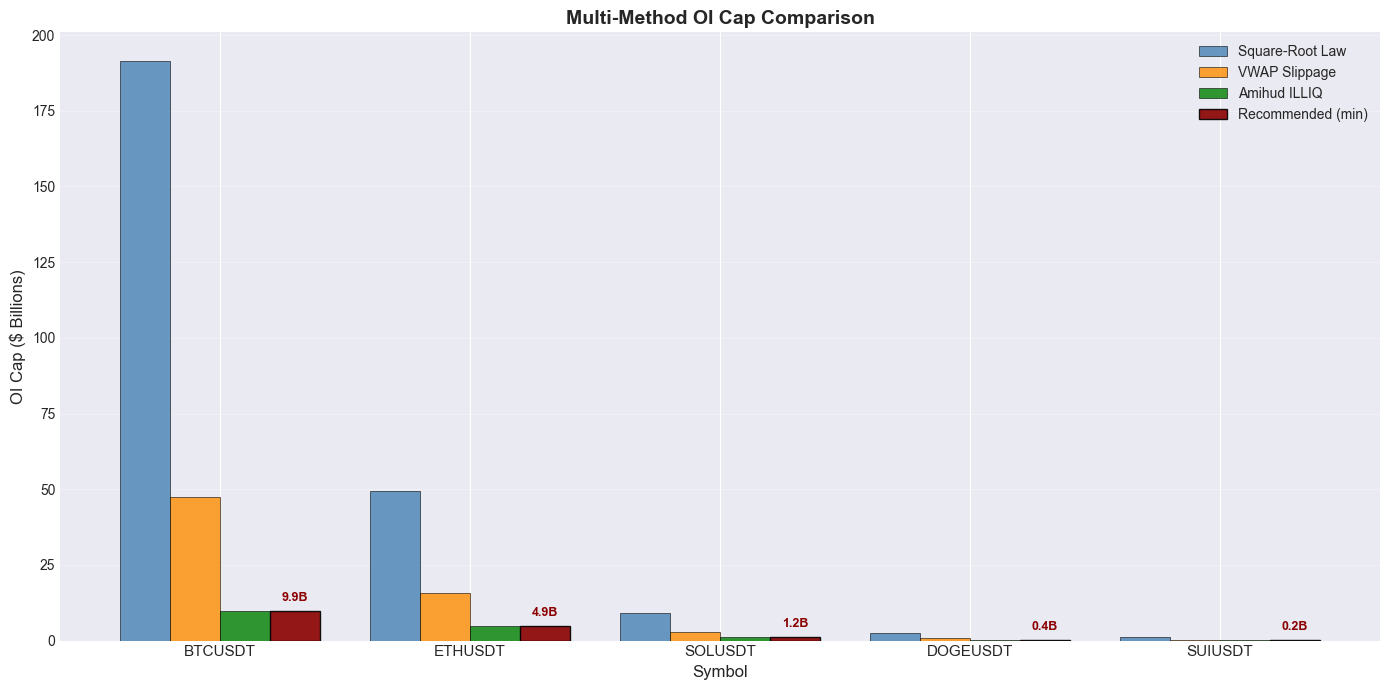

In [13]:
# Grouped bar chart: OI caps per symbol
fig, ax = plt.subplots(figsize=(14, 7))

symbols_list = comp_df['Symbol'].tolist()
x = np.arange(len(symbols_list))
width = 0.2

bars1 = ax.bar(x - 1.5*width, comp_df['OI SqrtLaw'] / 1e9, width,
               label='Square-Root Law', color='steelblue', alpha=0.8,
               edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x - 0.5*width, comp_df['OI VWAP'] / 1e9, width,
               label='VWAP Slippage', color='darkorange', alpha=0.8,
               edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + 0.5*width, comp_df['OI ILLIQ'] / 1e9, width,
               label='Amihud ILLIQ', color='green', alpha=0.8,
               edgecolor='black', linewidth=0.5)
bars4 = ax.bar(x + 1.5*width, comp_df['OI Recommended'] / 1e9, width,
               label='Recommended (min)', color='darkred', alpha=0.9,
               edgecolor='black', linewidth=1)

ax.set_xlabel('Symbol', fontsize=12)
ax.set_ylabel('OI Cap ($ Billions)', fontsize=12)
ax.set_title('Multi-Method OI Cap Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(symbols_list, fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

# Value labels on recommended bars
for bar in bars4:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}B',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()

In [14]:
# Tier classification based on recommended OI cap
def classify_tier(oi_cap):
    if pd.isna(oi_cap):
        return 'Tier 4 (Illiquid)'
    elif oi_cap >= 5e9:
        return 'Tier 1 (Highly Liquid)'
    elif oi_cap >= 500e6:
        return 'Tier 2 (Moderate)'
    elif oi_cap >= 50e6:
        return 'Tier 3 (Lower Liquidity)'
    else:
        return 'Tier 4 (Illiquid)'

comp_df['Tier'] = comp_df['OI Recommended'].apply(classify_tier)

# P10 (conservative) OI caps for final recommendation
conservative = []
for symbol in SYMBOLS:
    if symbol not in klines:
        continue
    df = klines[symbol]

    # Min across methods at each timestamp
    df['OI_min'] = df[['OI_sqrtlaw', 'OI_vwap', 'OI_illiq']].min(axis=1)
    p10_min = df['OI_min'].quantile(0.10)
    median_min = df['OI_min'].median()

    conservative.append({
        'Symbol': symbol,
        'Tier': comp_df.loc[comp_df['Symbol'] == symbol, 'Tier'].values[0],
        'OI Recommended (Median)': median_min,
        'OI Recommended (P10)': p10_min,
        'Binding Method': comp_df.loc[comp_df['Symbol'] == symbol, 'Binding Method'].values[0],
        'Method Divergence': comp_df.loc[comp_df['Symbol'] == symbol, 'Divergence'].values[0],
    })

final_df = pd.DataFrame(conservative)

display(HTML('<h3 style="text-align: center; margin-top: 20px; margin-bottom: 10px; font-weight: bold;">RECOMMENDED OI CAPS</h3>'))
display(final_df.style.format({
    'OI Recommended (Median)': lambda x: fmt_dollars(x),
    'OI Recommended (P10)': lambda x: fmt_dollars(x),
    'Method Divergence': '{:.1f}x',
}))

# Summary by tier
print("\nSummary by Tier:")
print("=" * 60)
for tier in final_df['Tier'].unique():
    tier_data = final_df[final_df['Tier'] == tier]
    symbols_in_tier = ', '.join(tier_data['Symbol'].tolist())
    avg_oi = tier_data['OI Recommended (Median)'].mean()
    print(f"  {tier}: {symbols_in_tier}")
    print(f"    Avg OI Cap (Median): {fmt_dollars(avg_oi)}")

,Symbol,Tier,OI Recommended (Median),OI Recommended (P10),Binding Method,Method Divergence
0,BTCUSDT,Tier 1 (Highly Liquid),$9.89B,$6.66B,ILLIQ,19.3x
1,ETHUSDT,Tier 2 (Moderate),$4.90B,$2.66B,ILLIQ,10.0x
2,SOLUSDT,Tier 2 (Moderate),$1.16B,$716.7M,ILLIQ,7.8x
3,DOGEUSDT,Tier 3 (Lower Liquidity),$347.7M,$196.1M,ILLIQ,7.6x
4,SUIUSDT,Tier 3 (Lower Liquidity),$172.2M,$93.1M,ILLIQ,6.0x



Summary by Tier:
  Tier 1 (Highly Liquid): BTCUSDT
    Avg OI Cap (Median): $9.89B
  Tier 2 (Moderate): ETHUSDT, SOLUSDT
    Avg OI Cap (Median): $3.03B
  Tier 3 (Lower Liquidity): DOGEUSDT, SUIUSDT
    Avg OI Cap (Median): $259.9M


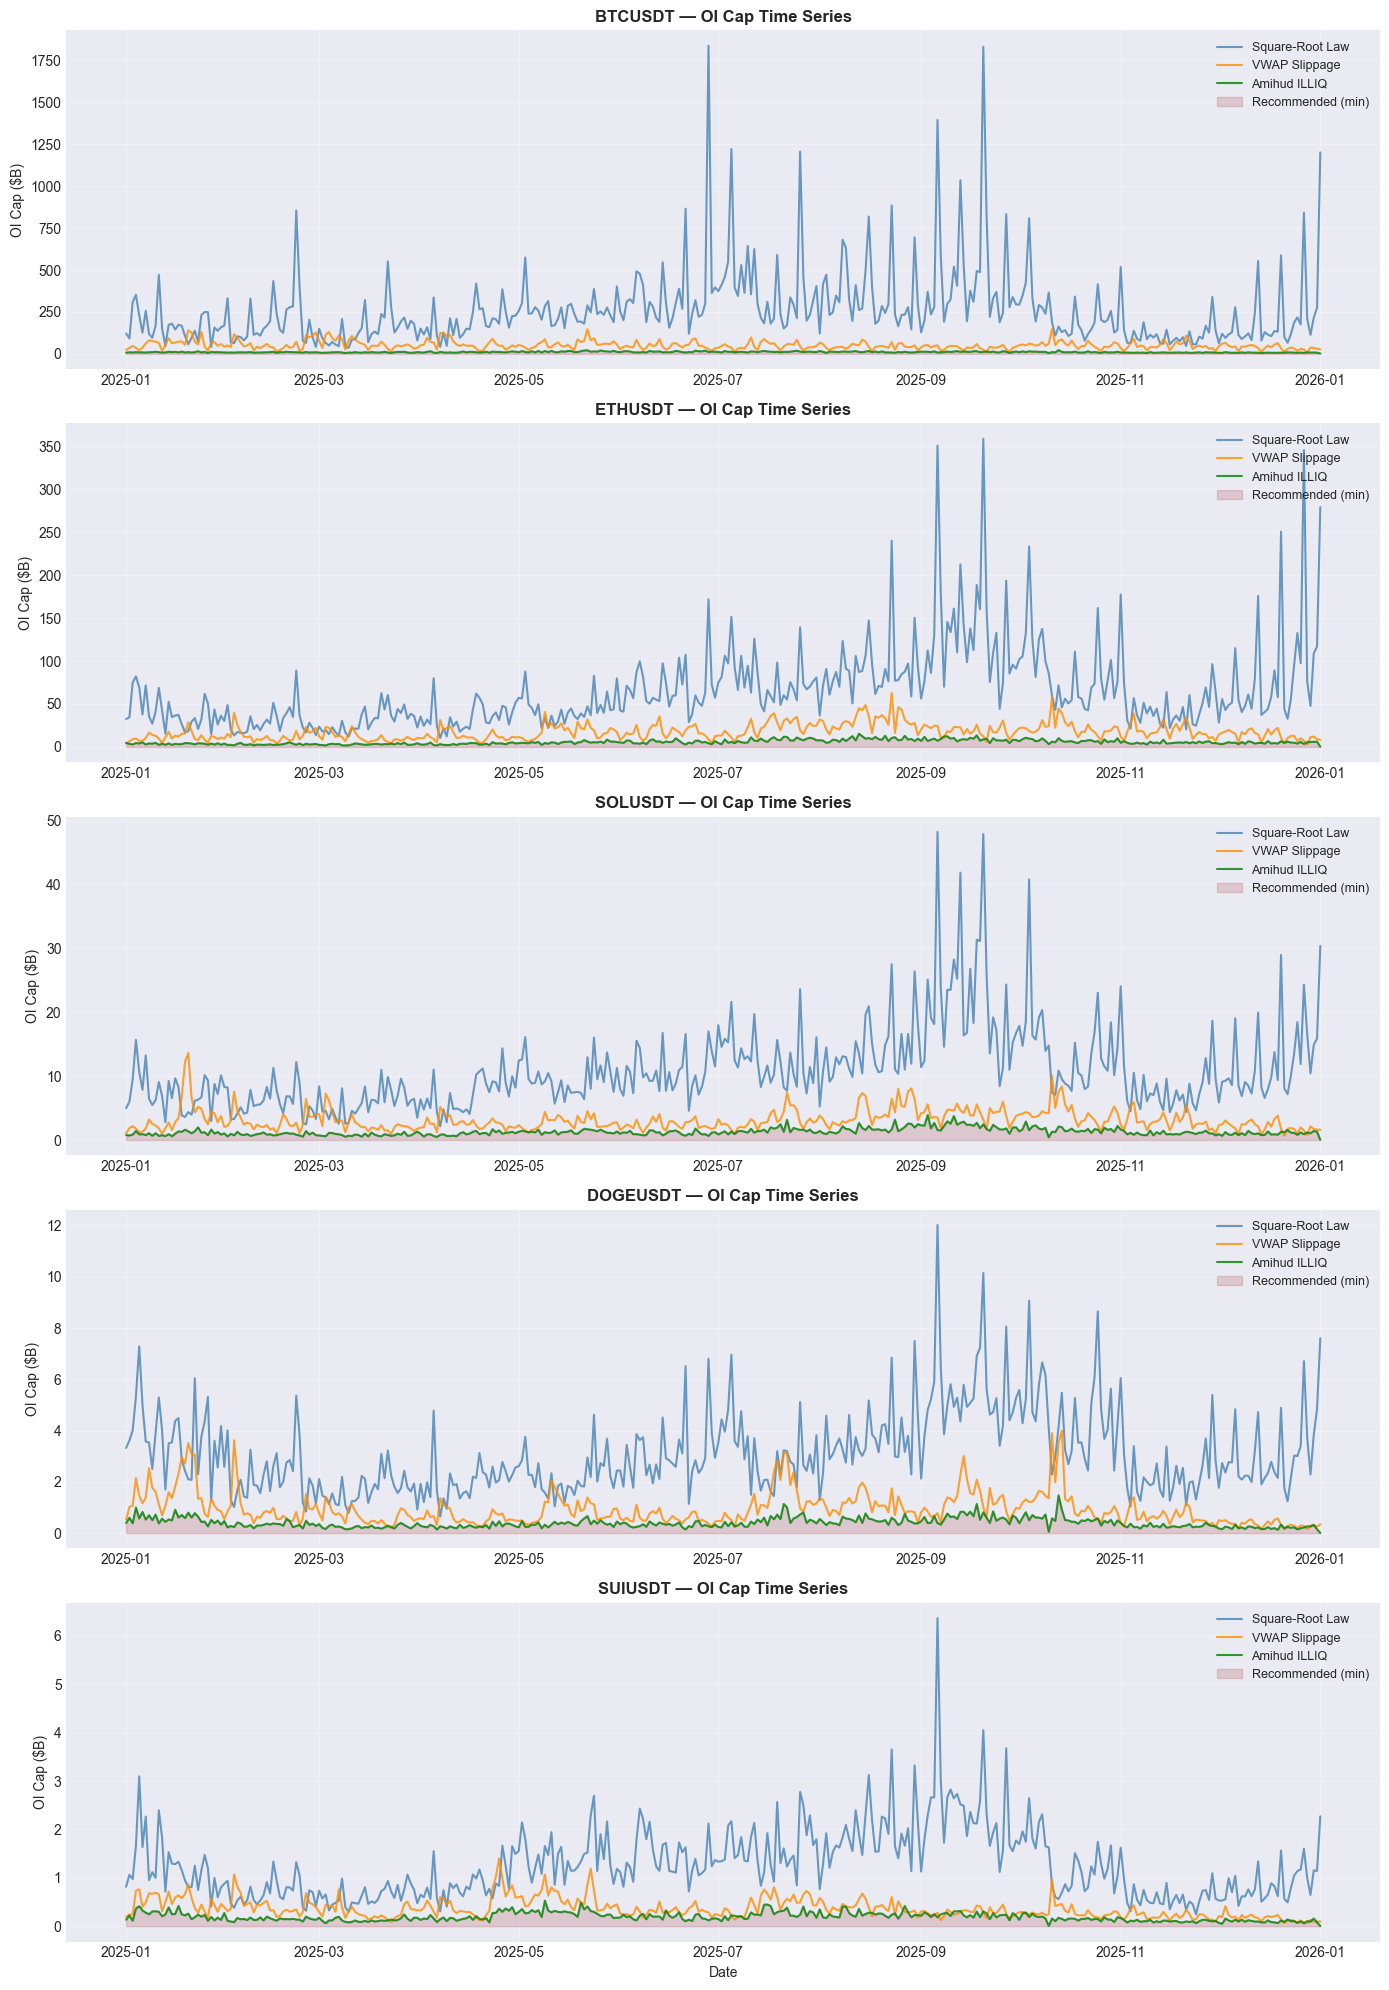

In [15]:
# Time series of OI caps for all symbols (daily resampled)
n = len([s for s in SYMBOLS if s in klines])
fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n))
if n == 1:
    axes = [axes]

for idx, symbol in enumerate([s for s in SYMBOLS if s in klines]):
    ax = axes[idx]
    df = klines[symbol]

    # Resample to daily for clean visualization
    daily = df[['OI_sqrtlaw', 'OI_vwap', 'OI_illiq']].resample('D').median()

    ax.plot(daily.index, daily['OI_sqrtlaw'] / 1e9, label='Square-Root Law',
            linewidth=1.5, color='steelblue', alpha=0.8)
    ax.plot(daily.index, daily['OI_vwap'] / 1e9, label='VWAP Slippage',
            linewidth=1.5, color='darkorange', alpha=0.8)
    ax.plot(daily.index, daily['OI_illiq'] / 1e9, label='Amihud ILLIQ',
            linewidth=1.5, color='green', alpha=0.8)

    # Recommended (min)
    daily['OI_min'] = daily[['OI_sqrtlaw', 'OI_vwap', 'OI_illiq']].min(axis=1)
    ax.fill_between(daily.index, 0, daily['OI_min'] / 1e9,
                     alpha=0.15, color='darkred', label='Recommended (min)')

    ax.set_title(f'{symbol} — OI Cap Time Series', fontsize=12, fontweight='bold')
    ax.set_ylabel('OI Cap ($B)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

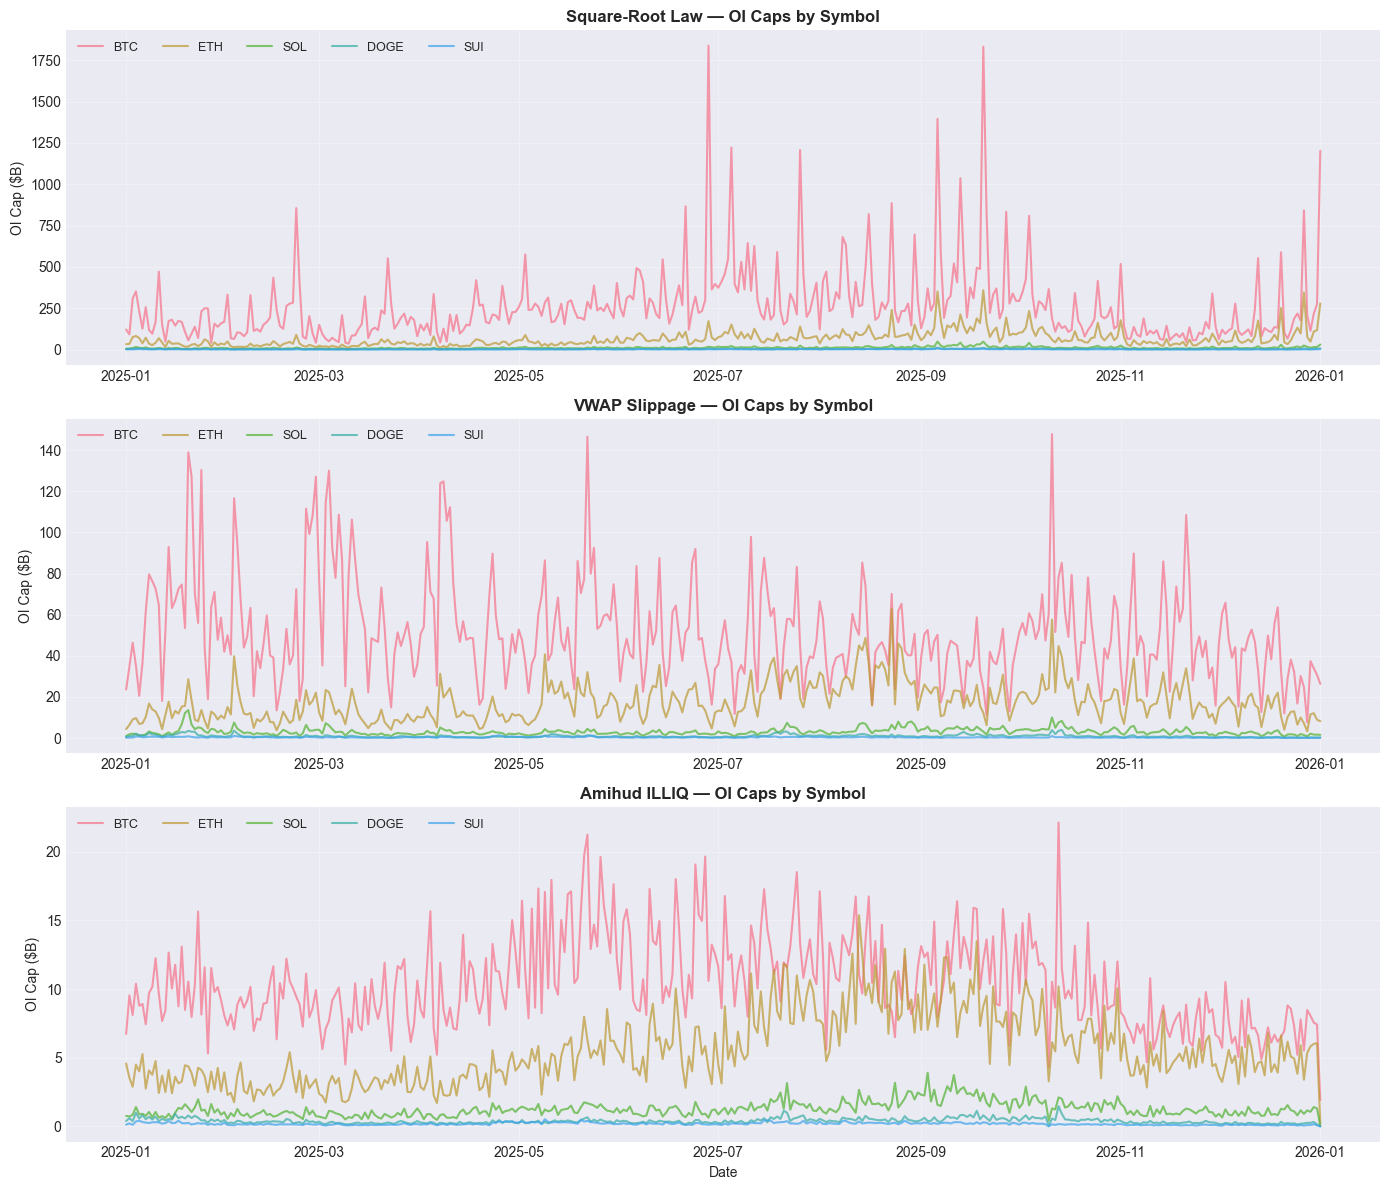

In [16]:
# Cross-symbol comparison: Each method on separate subplot
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

method_names = ['Square-Root Law', 'VWAP Slippage', 'Amihud ILLIQ']
method_cols = ['OI_sqrtlaw', 'OI_vwap', 'OI_illiq']
colors = ['steelblue', 'darkorange', 'green']

for idx, (method_name, method_col, color) in enumerate(zip(method_names, method_cols, colors)):
    ax = axes[idx]

    for symbol in [s for s in SYMBOLS if s in klines]:
        df = klines[symbol]
        daily = df[[method_col]].resample('D').median()

        # Scale to billions for readability
        ax.plot(daily.index, daily[method_col] / 1e9,
                label=symbol.replace('USDT', ''),
                linewidth=1.5, alpha=0.7)

    ax.set_title(f'{method_name} — OI Caps by Symbol', fontsize=12, fontweight='bold')
    ax.set_ylabel('OI Cap ($B)')
    ax.legend(loc='upper left', fontsize=9, ncol=5)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

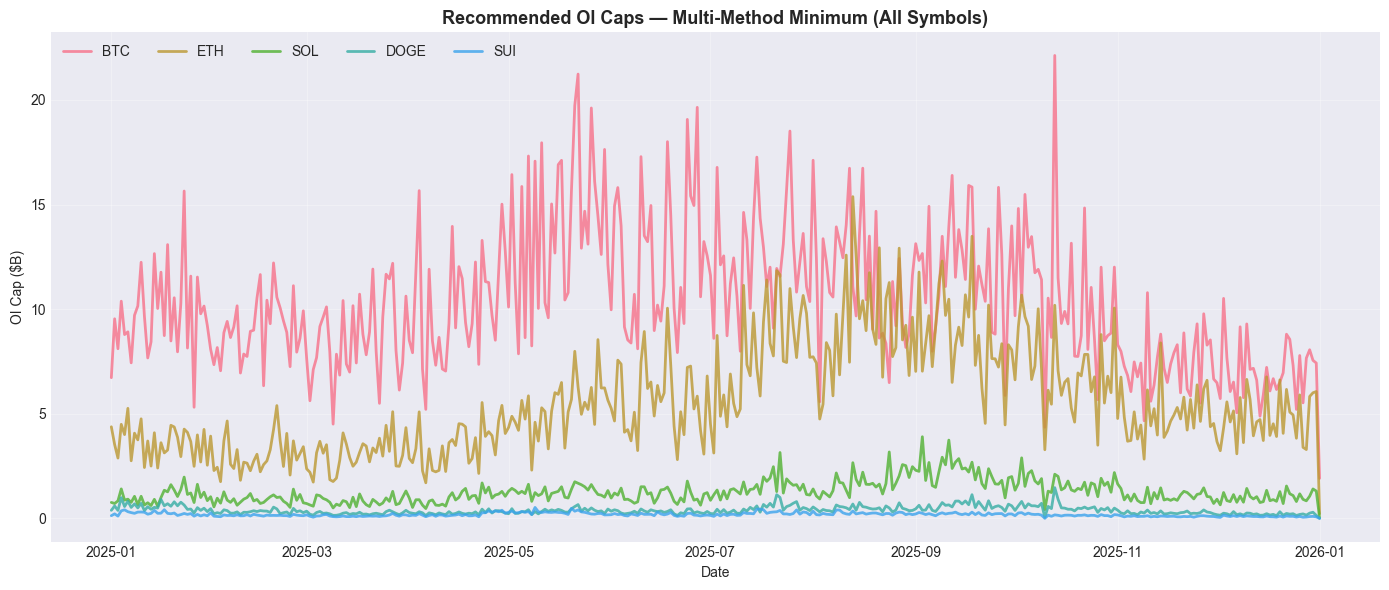

In [17]:
# Recommended OI caps (minimum of all methods) - All symbols
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

for symbol in [s for s in SYMBOLS if s in klines]:
    df = klines[symbol]
    daily = df[['OI_sqrtlaw', 'OI_vwap', 'OI_illiq']].resample('D').median()
    daily['OI_recommended'] = daily[['OI_sqrtlaw', 'OI_vwap', 'OI_illiq']].min(axis=1)

    ax.plot(daily.index, daily['OI_recommended'] / 1e9,
            label=symbol.replace('USDT', ''),
            linewidth=2, alpha=0.8)

ax.set_title('Recommended OI Caps — Multi-Method Minimum (All Symbols)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('OI Cap ($B)')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=10, ncol=5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Export Results

In [18]:
# Export results to parquet
export_data = []
for symbol in SYMBOLS:
    if symbol not in klines:
        continue
    df = klines[symbol]

    export_cols = ['close', 'volume', 'vol_1h', 'dollar_volume_1h_avg',
                   'OI_sqrtlaw', 'OI_vwap', 'ILLIQ_24h', 'OI_illiq']
    export_df = df[[c for c in export_cols if c in df.columns]].copy()
    export_df['symbol'] = symbol
    export_df['timestamp'] = export_df.index

    # Add recommended OI (min of all methods)
    oi_cols = [c for c in ['OI_sqrtlaw', 'OI_vwap', 'OI_illiq'] if c in export_df.columns]
    export_df['OI_recommended'] = export_df[oi_cols].min(axis=1)

    export_data.append(export_df)

# Combine and save
result_df = pd.concat(export_data, ignore_index=True)
output_path = RESULTS_DIR / '03_oi_caps_multimethod.parquet'
result_df.to_parquet(output_path, index=False)

print(f"Exported to: {output_path}")
print(f"  Records: {len(result_df):,}")
print(f"  Symbols: {result_df['symbol'].nunique()}")
print(f"  Columns: {result_df.columns.tolist()}")
print(f"\nFile size: {output_path.stat().st_size / 1e6:.1f} MB")

Exported to: results/03_oi_caps_multimethod.parquet
  Records: 2,628,005
  Symbols: 5
  Columns: ['close', 'volume', 'vol_1h', 'dollar_volume_1h_avg', 'OI_sqrtlaw', 'OI_vwap', 'ILLIQ_24h', 'OI_illiq', 'symbol', 'timestamp', 'OI_recommended']

File size: 128.4 MB


In [19]:
# Export summary table (one row per symbol)
summary_export = final_df.copy()

# Add per-method values
for _, row in comp_df.iterrows():
    symbol = row['Symbol']
    mask = summary_export['Symbol'] == symbol
    summary_export.loc[mask, 'OI_SqrtLaw_Median'] = row['OI SqrtLaw']
    summary_export.loc[mask, 'OI_VWAP_Median'] = row['OI VWAP']
    summary_export.loc[mask, 'OI_ILLIQ_Median'] = row['OI ILLIQ']

summary_path = RESULTS_DIR / '03_oi_caps_summary.csv'
summary_export.to_csv(summary_path, index=False)

print(f"\nSummary exported to: {summary_path}")
display(summary_export)


Summary exported to: results/03_oi_caps_summary.csv


,Symbol,Tier,OI Recommended (Median),OI Recommended (P10),Binding Method,Method Divergence,OI_SqrtLaw_Median,OI_VWAP_Median,OI_ILLIQ_Median
0,BTCUSDT,Tier 1 (Highly Liquid),9894936157.300798,6663874511.719357,ILLIQ,19.281467,191343425780.605896,47469088254.922462,9923696643.803316
1,ETHUSDT,Tier 2 (Moderate),4895505132.871122,2664481265.826273,ILLIQ,10.000186,49468000397.684097,15807839519.268250,4946708212.003307
2,SOLUSDT,Tier 2 (Moderate),1159743162.134905,716692412.843865,ILLIQ,7.763134,9084932310.321159,2728092961.708866,1170266124.765488
3,DOGEUSDT,Tier 3 (Lower Liquidity),347745697.737636,196139182.458797,ILLIQ,7.553278,2657145001.215925,753710470.934598,351786989.037896
4,SUIUSDT,Tier 3 (Lower Liquidity),172151384.405614,93114320.647689,ILLIQ,6.009323,1048730464.691499,313986218.376608,174517229.102575


## Conclusion

### Key Findings

1. **Multi-method OI caps** have been calculated using three independent approaches:
   - **Square-Root Law**: Theoretically grounded, uses **hourly volatility** matched to 1-hour liquidation window
   - **VWAP Slippage**: Empirically calibrated from historical price deviations (R² > 0.94)
   - **Amihud ILLIQ**: Conservative baseline from Notebook 01

2. **Conservative framework**: The recommended OI cap is the **minimum** across all three methods at each point in time, ensuring safety even if one method overestimates liquidity.

3. **Tier classification** naturally emerges from the OI cap magnitudes, with BTC/ETH in higher tiers and smaller assets in lower tiers.

4. **Dimensional consistency**: Square-Root Law now uses time-scale matched σ_1h and V_1h, ensuring the participation rate Q/V_1h is dimensionless as required by market microstructure theory.

### Methodological Notes

- **Square-Root Law**: Uses **hourly volatility** (σ_1h = σ_1m × √60) with hourly volume to maintain dimensional consistency for the 1-hour liquidation window. The participation rate Q/V_1h is dimensionless, as required by Bouchaud et al. (2009).
- **VWAP Slippage**: Empirically calibrated beta coefficients per-symbol capture actual market slippage behavior with high fidelity.
- **Amihud ILLIQ**: Daily metric, inherently conservative due to α = 0.4 safety factor.

### Dimensional Consistency Fix (Critical Update)

**Previous Error**: The original implementation incorrectly mixed daily volatility (σ_daily) with hourly volume (V_1h), violating dimensional consistency and underestimating OI caps by ~24×.

**Correction**: Now uses σ_1h with V_1h, ensuring Q/V_1h is a proper dimensionless participation rate. This aligns with the foundational principle from Bouchaud et al. (2009) that "dimensional consistency analysis singles out the square-root relation as the unique scaling law."

### Limitations

- **Square-Root Law**: Y coefficient is still a global default (Y=1.0); per-symbol calibration could improve accuracy
- **VWAP Slippage**: Extrapolation beyond observed volume levels; assumes square-root relationship holds
- **Amihud ILLIQ**: Daily frequency metric, not granular for intraday events
- **All methods**: Assume normal market conditions; flash crashes may require additional safety margins

### Next Steps

1. **Backtesting**: Validate OI caps against historical liquidation events
2. **Y Calibration**: Per-symbol calibration of Square-Root Law impact coefficient
3. **Regime-based adjustments**: Dynamic OI caps that tighten during high-volatility regimes
4. **Real-time monitoring**: Production dashboard for continuous OI limit tracking
5. **Asymmetric caps**: Separate limits for long vs short OI liquidation